# ResNet testing figures

In [1]:
import csv
import json
import re
import sys
import time
import os
import numpy as np
import torch
from pathlib import Path
from argparse import ArgumentParser


In [2]:
evaluation_id = "02-27_multi_category_resolution"

# config_path = "/home/ap/cloud/Master/aris_master/testing/02-19_normal-wood_impregnated-wood_1024_splits_final/config.json"

test_folder_path = "/home/ap/cloud/master/aris_master/testing"

In [3]:
def fetch_results_by_evaluation_id(evaluation_id, base_folder=test_folder_path, json_filename = "results.json", force=False):
    """
    Find all 'results.json' files under base_folder and ensure each file contains
    a 'unique_evaluation_id' equal to the provided evaluation_id.

    Returns:
        list[Path]: Paths to matching results.json files.

    Raises:
        FileNotFoundError: If no results.json files are found.
        ValueError: If a file is missing 'unique_evaluation_id' or has a mismatched value.
        json.JSONDecodeError: If a results.json file is invalid JSON.
    """
    base_path = Path(base_folder)
    results_files = list(base_path.rglob(json_filename))

    if not results_files:
        raise FileNotFoundError(f"No '{json_filename}' files found in: {base_path}")

    matching_files = []

    for file_path in results_files:
        with file_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        if "evaluation_id" not in data and not force:
            print(f"Skipping {file_path} due to missing 'evaluation_id'")
            continue
        
        if not force:
            if data["evaluation_id"] != evaluation_id:
                print(f"Skipping {file_path} due to mismatched evaluation_id: {data['evaluation_id']}")
                continue
    

        matching_files.append(file_path)

    return matching_files


In [4]:
# Fetch results files matching the evaluation_id
y_list = fetch_results_by_evaluation_id(evaluation_id, test_folder_path)
print(y_list)
y_mean = []
y_std = []
x = []
for result_file in y_list:
    with result_file.open("r", encoding="utf-8") as f:
        data = json.load(f)

    for entry in data["splits"]:
        if entry["synthetic_image_count"] == 0:
            val_acc = []
            f1_score = []
            for run in entry["runs"]:
                val_acc.append(run["val_accuracy"])
                f1_score.append(run["f1_score"])
            # Calculate mean and std for val_acc and f1_score
            val_acc_mean = np.mean(val_acc)
            val_acc_std = np.std(val_acc)
            f1_score_mean = np.mean(f1_score)

            f1_score_std = np.std(f1_score)
            y_mean.append(float(val_acc_mean))
            y_std.append(float(val_acc_std))
            x.append(data["independent_variable_value"])

print(x)
print(y_mean)
print(y_std)


Skipping /home/ap/cloud/master/aris_master/testing/02-27_resolution_5_class/resolution_256/results.json due to mismatched evaluation_id: 02-27_multi_category_resolution_5_class
Skipping /home/ap/cloud/master/aris_master/testing/02-27_resolution_5_class/resolution_64/results.json due to mismatched evaluation_id: 02-27_multi_category_resolution_5_class
Skipping /home/ap/cloud/master/aris_master/testing/02-27_resolution_5_class/resolution_384/results.json due to mismatched evaluation_id: 02-27_multi_category_resolution_5_class
Skipping /home/ap/cloud/master/aris_master/testing/02-27_resolution_5_class/resolution_512/results.json due to mismatched evaluation_id: 02-27_multi_category_resolution_5_class
Skipping /home/ap/cloud/master/aris_master/testing/02-27_resolution_5_class/resolution_96/results.json due to mismatched evaluation_id: 02-27_multi_category_resolution_5_class
Skipping /home/ap/cloud/master/aris_master/testing/02-27_resolution_5_class/resolution_1024/results.json due to misma

In [25]:
# Keep x and y values linked while sorting
# Use y if plotting simple y vs x, or y_mean/y_std for error bars.

# Simple y vs x:
xy_sorted = sorted(zip(x, y_mean), key=lambda t: t[0])
x_sorted, y_sorted = map(list, zip(*xy_sorted))

# If using mean/std:
xyz_sorted = sorted(zip(x, y_mean, y_std), key=lambda t: t[0])
x_sorted, y_mean_sorted, y_std_sorted = map(list, zip(*xyz_sorted))
y_mean_sorted = [float(100*y) for y in y_mean_sorted]
y_std_sorted = [float(100*y) for y in y_std_sorted]

# 64 = 1
# 128 = 0.25
# 256 = 0.0625
# 512 = 0.03125
x_min = min(x_sorted)
x_scale = []
y_memory_normalized = []
for i in range(len(y_mean_sorted)):
    scale = (x_sorted[i] / x_min) ** 2
    x_scale.append(scale)
    y_memory_normalized.append(y_mean_sorted[i] / scale)
    print(f"Division: {1/scale:.6f} (x={x_sorted[i]}, scale={scale})")
print("y_memory_normalized:", y_memory_normalized)

print("x_sorted:", x_sorted)
print("y_sorted:", y_sorted)
print("y_mean_sorted:", y_mean_sorted)
print("y_std_sorted:", y_std_sorted)

Division: 1.000000 (x=64, scale=1.0)
Division: 0.444444 (x=96, scale=2.25)
Division: 0.250000 (x=128, scale=4.0)
Division: 0.081633 (x=224, scale=12.25)
Division: 0.062500 (x=256, scale=16.0)
Division: 0.027778 (x=384, scale=36.0)
Division: 0.015625 (x=512, scale=64.0)
Division: 0.006944 (x=768, scale=144.0)
Division: 0.005102 (x=896, scale=196.0)
Division: 0.003906 (x=1024, scale=256.0)
y_memory_normalized: [87.75583333333333, 40.02293333333333, 22.668625, 7.6097496598639465, 5.800633333333334, 2.6067305555555556, 1.4732380208333333, 0.6498291666666666, 0.48078486394557823, 0.36754479166666665]
x_sorted: [64, 96, 128, 224, 256, 384, 512, 768, 896, 1024]
y_sorted: [0.8775583333333333, 0.900516, 0.9067449999999999, 0.9321943333333333, 0.9281013333333333, 0.9384229999999999, 0.9428723333333333, 0.9357539999999999, 0.9423383333333334, 0.9409146666666667]
y_mean_sorted: [87.75583333333333, 90.0516, 90.6745, 93.21943333333334, 92.81013333333334, 93.8423, 94.28723333333333, 93.57539999999999

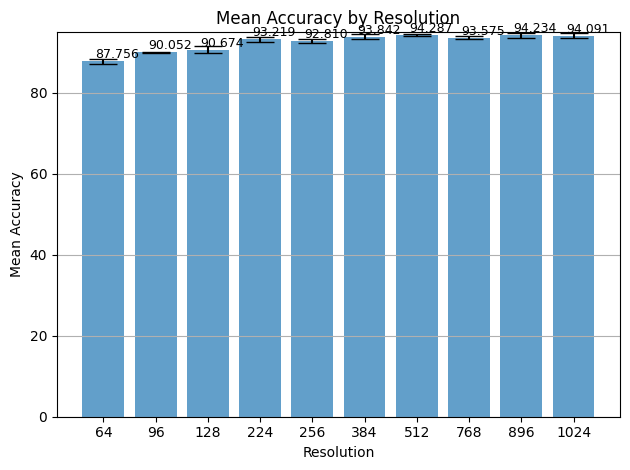

In [26]:
def bar_chart_with_error_bars(x, y_mean, y_std):
    import matplotlib.pyplot as plt
    import numpy as np

    x_pos = np.arange(len(x))

    bars = plt.bar(
        x_pos, y_mean, yerr=y_std, align='center',
        alpha=0.7, ecolor='black', capsize=10
    )
    plt.xticks(x_pos, x)
    plt.xlabel('Resolution')
    plt.ylabel('Mean Accuracy')
    plt.title('Mean Accuracy by Resolution')
    plt.grid(axis='y')

    # Add accuracy value on top of each bar
    y_max = max(m + s for m, s in zip(y_mean, y_std))
    plt.ylim(0, y_max + 0.05)
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2 + 0.27,
            height  + 0,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

bar_chart_with_error_bars(x_sorted, y_mean_sorted, y_std_sorted)

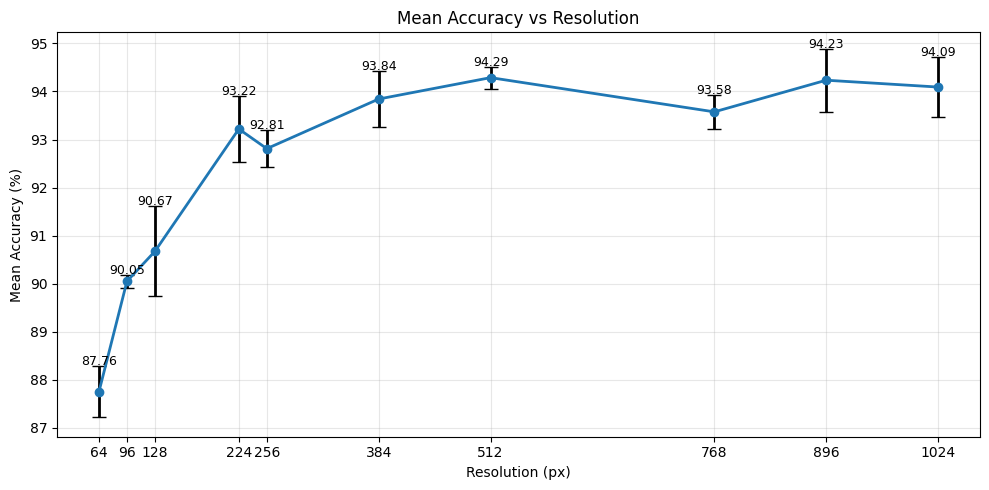

In [34]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    x_sorted,
    y_mean_sorted,
    yerr=y_std_sorted,
    fmt='o-',
    linewidth=2,
    capsize=5,
    ecolor='black'
)

ax.set_xlabel("Resolution (px)")
ax.set_ylabel("Mean Accuracy (%)")
ax.set_title("Mean Accuracy vs Resolution")

# Set x-axis to use actual values with relative spacing
ax.set_xscale("linear")
ax.set_xticks(x_sorted)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

# Grid lines aligned to x tick values
ax.grid(True, axis="both", alpha=0.3)
ax.set_axisbelow(True)

for xi, yi, ei in zip(x_sorted, y_mean_sorted, y_std_sorted):
    ax.text(xi, yi + ei + 0.02, f"{yi:.2f}", ha="center", fontsize=9)
ax.set_ylim(min(y_mean_sorted) - max(y_std_sorted), max(y_mean_sorted) + max(y_std_sorted) + 0.005)
plt.tight_layout()
# Save png
plt.savefig("accuracy_vs_resolution_4_classes.png", dpi=400)
plt.show()

## Accuracy normalized by memory usage

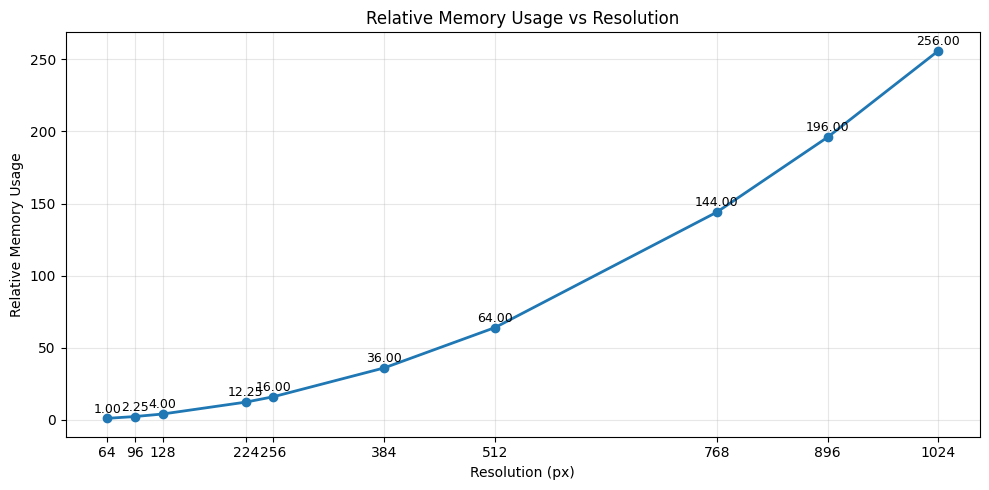

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_sorted, x_scale, 'o-', linewidth=2)

ax.set_xlabel("Resolution (px)")
ax.set_ylabel("Relative Memory Usage")
ax.set_title("Relative Memory Usage vs Resolution")

ax.set_xscale("linear")
ax.set_xticks(x_sorted)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

ax.grid(True, axis="both", alpha=0.3)
ax.set_axisbelow(True)

for xi, yi, scale in zip(x_sorted, y_memory_normalized, x_scale):
    ax.text(xi, scale +4, f"{scale:.2f}", ha="center", fontsize=9)

#ax.set_ylim(min(y_memory_normalized) - max(y_memory_normalized) * 0.05, max(y_memory_normalized) * 1.1)
plt.tight_layout()
plt.show()


# Data augmentation

In [29]:
# Find project root (folder that contains "src") starting from current working directory
from pathlib import Path
import sys


print("Successfully imported build_image_augmentations from augmentations.py")

Successfully imported build_image_augmentations from augmentations.py


In [30]:
import random
import numpy as np
import torch
from PIL import Image
from matplotlib import pyplot as plt
project_root = next(
	(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()),
	Path.cwd()
)

sys.path.insert(0, str(project_root))
import json
from src.waste_diffuser.augmentations import build_image_augmentations
config_path = project_root / "queue/TEST_DATA_AUGMENTATION.json"
with config_path.open("r", encoding="utf-8") as f:
    config = json.load(f)
print(config["augmentation"])
# Create augmentations
augmentations = build_image_augmentations(config)
print("Successfully created augmentations pipeline from config")
def _resolve_path(p):
    p = Path(p)
    return p if p.is_absolute() else (project_root / p)

def _find_train_dirs(cfg):
    dirs = []

    # Common top-level keys
    for key in ("train_dir", "train_data_dir", "data_dir"):
        v = cfg.get("data", {}).get(key)
        if isinstance(v, str):
            rp = _resolve_path(v)
            if rp.exists():
                dirs.append(rp)

    # Class-level directories
    classes_cfg = cfg.get("data", {}).get("classes", {})
    if isinstance(classes_cfg, dict):
        for _, class_info in classes_cfg.items():
            if not isinstance(class_info, dict):
                continue
            for key in ("train_dir", "train_data_dir", "real_data_dir", "data_dir"):
                v = class_info.get(key)
                if isinstance(v, str):
                    rp = _resolve_path(v)
                    if rp.exists():
                        dirs.append(rp)

    # De-duplicate while preserving order
    seen = set()
    unique_dirs = []
    for d in dirs:
        if d not in seen:
            seen.add(d)
            unique_dirs.append(d)

    return unique_dirs

def _get_train_transform(augs):
    if isinstance(augs, dict):
        for k in ("train", "training", "train_transform"):
            if k in augs:
                return augs[k]
    return augs

train_dirs = _find_train_dirs(config)
if not train_dirs:
    raise FileNotFoundError("No train directory found in config.")

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths = []
for d in train_dirs:
    image_paths.extend([p for p in d.rglob("*") if p.suffix.lower() in image_exts])

if not image_paths:
    raise FileNotFoundError(f"No images found in train directories: {train_dirs}")

transform = _get_train_transform(augmentations)
print(f"Using transform: {transform}")

n_images = min(4, len(image_paths))
n_augments = 4
selected = random.sample(image_paths, n_images)

fig, axes = plt.subplots(n_images, n_augments + 1, figsize=(3.2 * (n_augments + 1), 3.2 * n_images))
if n_images == 1:
    axes = [axes]

for r, img_path in enumerate(selected):
    img = np.array(Image.open(img_path).convert("RGB"))

    # Original
    axes[r][0].imshow(img)
    axes[r][0].set_title(f"Original\n{img_path.name}", fontsize=9)
    axes[r][0].axis("off")

    # Augmented variants
    for c in range(1, n_augments + 1):
        out = transform(img)
        aug = out["image"] if isinstance(out, dict) and "image" in out else out

        if torch.is_tensor(aug):
            aug = aug.detach().cpu()
            if aug.ndim == 3 and aug.shape[0] in (1, 3, 4):
                aug = aug.permute(1, 2, 0)
            aug = aug.numpy()

        if isinstance(aug, np.ndarray) and aug.dtype != np.uint8:
            if aug.min() < 0.0:
                aug = (((aug + 1.0) / 2.0) * 255.0).clip(0, 255).astype(np.uint8)
            elif aug.max() <= 1.0:
                aug = (aug * 255.0).clip(0, 255).astype(np.uint8)
            else:
                aug = aug.clip(0, 255).astype(np.uint8)

        axes[r][c].imshow(aug)
        axes[r][c].set_title(f"Aug {c}", fontsize=9)
        axes[r][c].axis("off")

plt.tight_layout()
plt.show()

print("Train directories used:")
for d in train_dirs:
    print("-", d)
print(f"Images found: {len(image_paths)}")

{'use_data_augmentations_real': False, 'use_data_augmentations_synthetic': True, 'affine': {'interpolation': 2, 'p': 0.0, 'rotate': {'max': 45, 'min': -45}, 'scale': {'max': 1.2, 'min': 0.8}, 'shear': {'max': 10, 'min': -10}, 'translate_percent': {'max': 0.15, 'min': -0.15}}, 'brightness_contrast': {'brightness_limit': {'max': 0.4, 'min': -0.2}, 'contrast_limit': {'max': 0.2, 'min': -0.1}, 'p': 0.2}, 'clahe': {'clip_limit': 2.0, 'p': 0.25}, 'coarse_dropout': {'max_height': 100, 'max_width': 100, 'num_holes': {'max': 8, 'min': 2}, 'p': 0.2}, 'color_jitter': {'brightness': {'max': 1.2, 'min': 0.8}, 'contrast': {'max': 1.2, 'min': 0.8}, 'hue': 0.2, 'p': 0.2, 'saturation': {'max': 1.2, 'min': 0.8}}, 'defocus': {'alias_blur': {'max': 2, 'min': 1.5}, 'p': 0.3, 'radius': {'max': 13, 'min': 5}}, 'gauss_noise': {'mean_range': {'max': 1, 'min': -1}, 'p': 0.0, 'std_range': {'max': 10, 'min': 9}}, 'horizontal_flip': {'p': 0.4}, 'iso_noise': {'color_shift': {'max': 0.6, 'min': 0.2}, 'intensity': {'

FileNotFoundError: No train directory found in config.